In [12]:
import sys 
sys.path.insert(0, '..')

In [13]:
from __future__ import annotations
import numpy as np
import pandas as pd
import scipy.stats as st
from dataclasses import dataclass
import warnings
from matplotlib import pyplot as plt
from scipy.optimize import minimize

In [14]:
from panel_exp.panel_data import long_df_to_paneldataset
from panel_exp.methods.tbr import TBR, TBRRidge
from panel_exp.methods.scm import SyntheticControl, AugSynth
from panel_exp import panel_data

from panel_exp.inference.unit_jackknife import unit_jk

In [15]:
import seaborn as sns

sns.set_style("darkgrid")

In [16]:
data = pd.read_csv('/Users/christopherb/downloads/Paglayan.csv' )


In [17]:
data[['cbr', 'year', 'State', 'lnppexpend']].head()


,cbr,year,State,lnppexpend
0,0,1959,AK,8.154683
1,0,1960,AK,8.325518
2,0,1961,AK,8.374317
3,0,1962,AK,8.410700
4,0,1963,AK,8.445598


In [18]:
wide_df = pd.pivot_table(data, columns='year', index='State', values='lnppexpend')
i=wide_df.index
c=wide_df.columns

# de-mean
wide_df = pd.DataFrame(wide_df.values - wide_df.mean(axis=1).values.reshape(-1,1))
wide_df.index = i
wide_df.columns = c

treated = pd.pivot_table(data, columns='year', index='State', values='cbr')

In [19]:

treated_times = [panel_data.TimePeriod(start=treated.columns[treated.loc[s]==1][0], end=treated.columns[treated.loc[s]==1][-1]) for s in treated.index if len(treated.columns[treated.loc[s]==1])>0]
treated_units = [s for s in treated.index if len(treated.columns[treated.loc[s]==1])>0]
                 

In [26]:
wide_df.loc[treated_units]

year,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997
State,,,,,,,,,,,,,,,,,,,,,
AK,-0.960967,-0.790132,-0.741333,-0.704950,-0.670052,-0.645797,-0.629372,-0.508803,-0.428761,-0.414169,...,0.340992,0.381737,0.319121,0.323494,0.300059,0.277976,0.261878,0.253101,0.229171,0.211283
CA,-0.486425,-0.453382,-0.434666,-0.473957,-0.508787,-0.389886,-0.339522,-0.371927,-0.245586,-0.305516,...,0.316910,0.338312,0.306062,0.274541,0.239261,0.232088,0.223753,0.224264,0.258478,0.306335
CT,-0.864918,-0.780281,-0.729671,-0.687325,-0.657550,-0.590948,-0.542060,-0.532912,-0.382496,-0.395298,...,0.546173,0.628744,0.599034,0.567431,0.542438,0.550272,0.578124,0.556077,0.544620,0.558709
DE,-0.706696,-0.647085,-0.627724,-0.564536,-0.547124,-0.574823,-0.562436,-0.465114,-0.325641,-0.364018,...,0.375404,0.400003,0.371808,0.356019,0.353574,0.382762,0.421142,0.422614,0.456969,0.473502
FL,-0.866746,-0.755069,-0.713638,-0.668372,-0.622671,-0.585514,-0.546856,-0.494028,-0.345985,-0.248552,...,0.447284,0.488143,0.490945,0.441769,0.423499,0.431623,0.436865,0.419529,0.406380,0.418902
HI,-0.860808,-0.831169,-0.788851,-0.728026,-0.675069,-0.637368,-0.482732,-0.251636,-0.291547,-0.232465,...,0.270510,0.296010,0.397810,0.405667,0.427866,0.435279,0.421701,0.387058,0.371058,0.387514
IA,-0.793771,-0.694306,-0.648891,-0.618753,-0.597091,-0.596868,-0.417558,-0.428308,-0.260887,-0.245622,...,0.303387,0.295997,0.296318,0.337131,0.343187,0.333674,0.341472,0.358445,0.375161,0.396800
ID,-0.698802,-0.605603,-0.567352,-0.532250,-0.507814,-0.540933,-0.392742,-0.396089,-0.203990,-0.172513,...,0.213644,0.261663,0.302219,0.310709,0.310853,0.325540,0.386870,0.417244,0.446640,0.483738
IL,-0.710193,-0.592348,-0.542873,-0.535911,-0.539106,-0.465333,-0.416992,-0.453410,-0.296491,-0.296951,...,0.328467,0.339679,0.368457,0.346998,0.376485,0.350031,0.367025,0.332980,0.377404,0.404256


In [20]:
penalty_strength = 0.01
penalty = "l2"

In [27]:
y = wide_df.loc[treated_units]

In [31]:
X = wide_df.loc[[unit for unit in wide_df.index if unit not in treated_units]]

In [33]:
y.shape

(32, 39)

In [45]:
wide_df.columns

Index([1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
       1995, 1996, 1997],
      dtype='int64', name='year')

In [47]:
def treated_mask():
    '''
    returns matrix of wide_df shape with zeros and one's where one's indicate treatment
    '''
    mask = []

    for u in range(len(treated_times)):
        trt = []
        for x in wide_df.columns:
            trt.append(1 if x >= treated_times[u].start and x<= treated_times[u].end else 0)
        mask.append(trt)

    mask = np.array(mask)
    
    return mask 
    

In [48]:
mask = treated_mask()

In [49]:
mask

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])

In [50]:
def balance_objective(x):
    # minimize the sum of squared errors
    # subject to an entropy penalty
    imbalance = np.sum(np.square(y_i - x_i @ x))
    if penalty == "entropy":
        imbalance += penalty_strength * -np.sum(x * np.log(x))
    elif penalty == "l1":
        imbalance += penalty_strength * np.sum(np.abs(x))
    elif penalty == "l2":
        imbalance += penalty_strength * np.sum(np.square(x))
    else:
        raise NotImplemented(f"Unknown penalty {penalty}")
    return imbalance

In [51]:
# mask indicates 1 for treated and 0 for pre-treatment
mask

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])

# Seperate Estimates

In [52]:
results = {}
weights_sep = []

for t_unit in enumerate(y.index):
    
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values #[-15:]
    x_i = X.T.iloc[t_i==0] #[-15:]
    
    
    
    x0 = np.ones(x_i.shape[1]) / x_i.shape[1]
    simplex_bounds = [(0, 1) for _ in range(x_i.shape[1])]
    simplex_constraints = [{"type": "eq", "fun": lambda x: np.sum(x) - 1}]
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        res = minimize(
            balance_objective,
            x0,
            method="SLSQP",
            bounds=simplex_bounds,
            constraints=simplex_constraints,
        )
        
    w_scm = res.x
    weights_sep.append(w_scm)
    
    pre_treatment_y_hat = x_i @ w_scm
    post_treatment_y_hat = X.T.iloc[t_i==1] @ w_scm
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    results[t_unit[1]]={}
    results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    results[t_unit[1]]['lagged_outcomes_te'] = results[t_unit[1]]['lagged_outcomes_act'] - results[t_unit[1]]['lagged_outcomes_est']
    results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
        
    
    
    
    


In [57]:
pd.DataFrame(results)

,AK,CA,CT,DE,FL,HI,IA,ID,IL,IN,...,NY,OH,OK,OR,PA,RI,SD,TN,VT,WA
lagged_outcomes_est,"[-0.8912929703334659, -0.8008165374389423, -0....","[-0.6096204877442286, -0.5603176429707769, -0....","[-0.8653654359746914, -0.7818496842458409, -0....","[-0.7417975214212422, -0.6677697225581124, -0....","[-0.8700433015318728, -0.763921865599973, -0.7...","[-0.8910432666472965, -0.8054500028596054, -0....","[-0.7972984975714665, -0.7132621311601642, -0....","[-0.7217552753602307, -0.636259422379931, -0.5...","[-0.7201761780884033, -0.6441258889161933, -0....","[-0.7022501943572602, -0.6211964910502822, -0....",...,"[-0.7828185831357286, -0.6999845002798972, -0....","[-0.7370755315240287, -0.6656631204133172, -0....","[-0.7403901087927177, -0.7082374404793288, -0....","[-0.7045384037895889, -0.6353182104026032, -0....","[-0.8220796005765278, -0.7587723879324331, -0....","[-0.8332944619735733, -0.7565845225117305, -0....","[-0.671081716590869, -0.5967905220323523, -0.5...","[-0.875865856118123, -0.7935600296037799, -0.7...","[-0.8671772165776522, -0.7990775056500736, -0....","[-0.6892605418879536, -0.6297626086277329, -0...."
lagged_outcomes_act,"[-0.9609673333333326, -0.7901323333333323, -0....","[-0.4864249102564102, -0.45338191025641095, -0...","[-0.8649183743589735, -0.7802811743589739, -0....","[-0.7066964102564093, -0.647085410256409, -0.6...","[-0.8667456153846169, -0.7550689153846166, -0....","[-0.8608076025641065, -0.831169202564106, -0.7...","[-0.793771266666667, -0.6943063666666669, -0.6...","[-0.6988024487179487, -0.6056030487179491, -0....","[-0.7101928076923087, -0.5923478076923079, -0....","[-0.7066941179487181, -0.6195902179487183, -0....",...,"[-0.8052389230769208, -0.7168259230769216, -0....","[-0.7182681974358962, -0.6748838974358957, -0....","[-0.7222677512820486, -0.6958981512820488, -0....","[-0.691884756410257, -0.6164637564102566, -0.5...","[-0.7769717641025622, -0.7376174641025628, -0....","[-0.8220708769230773, -0.7553379769230775, -0....","[-0.6650373717948712, -0.5782343717948715, -0....","[-0.8586849717948724, -0.7876000717948726, -0....","[-0.8490375564102575, -0.8138938564102576, -0....","[-0.6483650256410236, -0.6768131256410239, -0...."
lagged_outcomes_te,"[-0.06967436299986673, 0.010684204105609996, 0...","[0.1231955774878184, 0.10693573271436596, 0.09...","[0.00044706161571794745, 0.0015685098868669645...","[0.03510111116483294, 0.020684312301703422, -0...","[0.003297686147255896, 0.00885295021535637, -0...","[0.030235664083190006, -0.02571919970450054, -...","[0.003527230904799561, 0.01895576449349734, 0....","[0.02295282664228193, 0.030656373661981928, 0....","[0.009983370396094537, 0.051778081223885386, 0...","[-0.0044439235914578434, 0.0016062731015639153...",...,"[-0.02242033994119219, -0.016841422797024386, ...","[0.01880733408813251, -0.009220777022578508, -...","[0.01812235751066915, 0.012339289197280001, 0....","[0.012653647379331834, 0.01885445399234653, 0....","[0.04510783647396566, 0.021154923829870276, 0....","[0.011223585050495921, 0.001246545588653003, 0...","[0.0060443447959978025, 0.018556150237480806, ...","[0.0171808843232506, 0.005959957808907346, -0....","[0.018139660167394767, -0.01481635076018395, -...","[0.04089551624693, -0.04705051701329099, 0.039..."
lagged_time_units,"[-11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1,...","[-17, -16, -15, -14, -13, -12, -11, -10, -9, -...","[-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, ...","[-11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1,...","[-15, -14, -13, -12, -11, -10, -9, -8, -7, -6,...","[-11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1,...","[-16, -15, -14, -13, -12, -11, -10, -9, -8, -7...","[-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2...","[-25, -24, -23, -22, -21, -20, -19, -18, -17, ...","[-14, -13, -12, -11, -10, -9, -8, -7, -6, -5, ...",...,"[-9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, ...","[-25, -24, -23, -22, -21, -20, -19, -18, -17, ...","[-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2...","[-15, -14, -13, -12, -11, -10, -9, -8, -7, -6

AttributeError: Line2D.set() got an unexpected keyword argument 'size'

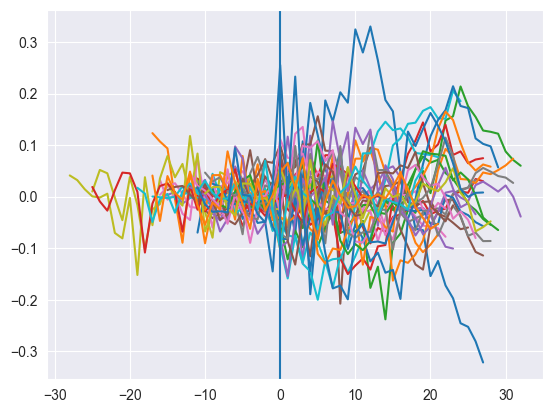

In [88]:
from collections import defaultdict 

lagged_df = {}

for k in results:
    
    r = zip(results[k]['lagged_time_units'], results[k]['lagged_outcomes_te'])
    
    for outcome in r:
        if outcome[0] not in lagged_df:
            lagged_df[outcome[0]] = []
            lagged_df[outcome[0]].append(outcome[1])
        elif outcome[0] in lagged_df:
            lagged_df[outcome[0]].append(outcome[1])
            
    
    plt.plot(results[k]['lagged_time_units'] , results[k]['lagged_outcomes_te'])

plt.axvline(0)
plt.plot(df['lagged'].values, df['mean'].values, color='red', size=3)

In [68]:
#[results[k]['lagged_outcomes_est'].shape for k in results.keys()]

df = pd.DataFrame([[k, np.mean(v)] for k, v in lagged_df.items()])

In [74]:
df.columns = ['lagged', 'mean']
df = df.sort_values(['lagged'])

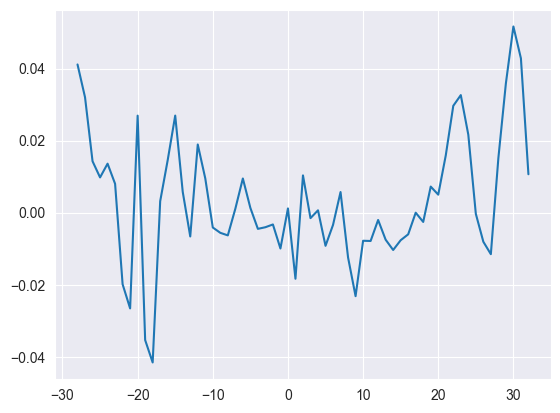

In [85]:
plt.plot(df['lagged'].values, df['mean'].values)

In [20]:
sep_df = np.empty((0,5))

for k in results:
    sep_df = np.concatenate([sep_df
                             , np.vstack([np.array(list([k]) * results[k]['lagged_outcomes_est'].shape[0]) 
                             , np.array(results[k]['lagged_time_units'])
                             , np.array(results[k]['lagged_outcomes_te'])
                             , np.array(results[k]['lagged_outcomes_act'])
                             , np.array(results[k]['lagged_outcomes_est'])]).T])



In [21]:
sep_df = pd.DataFrame(sep_df)
sep_df.columns =['state','lag', 'te', 'act', 'est']

In [22]:
lagged_df = pd.pivot_table(sep_df, index='state', columns='lag', values='te', fill_value=0).T
lagged_df.index = lagged_df.index.astype(int)
lagged_df = lagged_df.sort_index()

In [23]:
lagged_df[lagged_df == 0] = np.nan 

<AxesSubplot:xlabel='lag'>

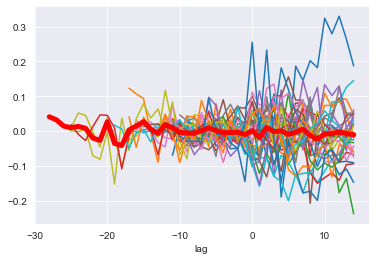

In [24]:
lagged_df[:-18].plot(legend=False)
lagged_df[:-18].mean(axis=1).plot(linewidth=5, color='red')

# Seperate Estimates. One Function

In [25]:
def sep_balance_objective(x): 
    x = x.reshape((17,32))
    
    state_imbalance = (test.T.values - np.dot(control, x)) * np.abs(mask-1).T
    state_imbalance[state_imbalance == 0] = np.nan 
    #imbalance = np.nansum((state_imbalance[:15:,]**2))
    imbalance = np.nansum((state_imbalance**2))
    
    if penalty == "entropy":
        imbalance += penalty_strength * -np.sum(x * np.log(x))
    elif penalty == "l1":
        imbalance += penalty_strength * np.sum(np.abs(x))
    elif penalty == "l2":
        imbalance += penalty_strength * np.sum(np.square(x))
    else:
        raise NotImplemented(f"Unknown penalty {penalty}")
    return imbalance


In [26]:
control = np.array(pand.wide_data.loc[[unit for unit in pand.units if unit not in pand.treated_units]]).T 
test = pand.wide_data.loc[pand.treated_units] #* np.abs(mask-1))

In [27]:
x0 = (np.ones((control.shape[1], test.shape[0])) /  control.shape[1] )#.flatten()
#x0=np.ones(544)/544
print(x0.shape)
print(control.shape)
print(test.shape)


(17, 32)
(39, 17)
(32, 39)


In [28]:
simplex_bounds = [(0, 1) for _ in range(544)]

def constraint(x):
    x = x.reshape(17,32)
    #return sum(x.sum(axis=0) - np.ones(32))
    return sum(np.isclose(x.sum(axis=0) - np.ones(32), 0)+1)

simplex_constraints = [{"type": "eq", "fun": constraint}]


In [29]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    res = minimize(
        sep_balance_objective,
        x0.flatten(),
        method="SLSQP",
        bounds=simplex_bounds,
        constraints={'type':'eq', 'fun': lambda x: np.sum(x.reshape(17,32), axis=0) - 1},
    )
        

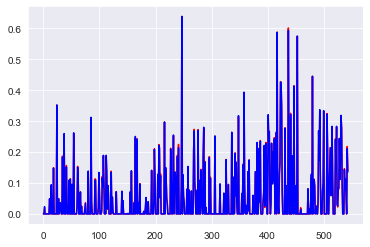

In [30]:
# compare weights 
plt.plot(res.x, color='red')
plt.plot(np.array(weights_sep).T.flatten(), color='blue')

In [31]:
results = {}


for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values#[-15:]
    x_i = X.T.iloc[t_i==0]#[-15:]
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    results[t_unit[1]]={}
    results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    results[t_unit[1]]['lagged_outcomes_te'] = results[t_unit[1]]['lagged_outcomes_act'] - results[t_unit[1]]['lagged_outcomes_est']
    results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
 

    

In [32]:
results_df = np.empty((0,5))

for k in results:
    results_df = np.concatenate([results_df
                             , np.vstack([np.array(list([k]) * len(results[k]['lagged_time_units'])) 
                             , np.array(results[k]['lagged_time_units'])
                             , np.array(results[k]['lagged_outcomes_te'])
                             , np.array(results[k]['lagged_outcomes_act'])
                             , np.array(results[k]['lagged_outcomes_est'])]).T])

In [33]:
results_df = pd.DataFrame(results_df)
results_df.columns =['state','lag', 'pte', 'act', 'est']

results_df['pte'] = results_df['pte'].astype(float)
results_df.lag = results_df.lag.astype(int)

In [34]:

results_df = pd.pivot_table(results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
results_df.index = results_df.index.astype(int)
results_df = results_df.sort_index()

results_df[results_df == 0] = np.nan 


In [35]:
print("ATT")
results_df[(results_df.index>=0)&(results_df.index<=10)].mean(axis=1)

ATT


lag
0     0.001119
1    -0.018423
2     0.010243
3    -0.001511
4     0.000528
5    -0.009377
6    -0.003388
7     0.005679
8    -0.012483
9    -0.023256
10   -0.007796
dtype: float64

In [36]:
results_df[(results_df.index>=0)&(results_df.index<=10)].mean(axis=1).mean()

-0.005333277103875305

In [37]:
lagged_df[(lagged_df.index>=0)&(lagged_df.index<=10)].mean(axis=1).mean()

-0.005272986033771306

<AxesSubplot:xlabel='lag'>

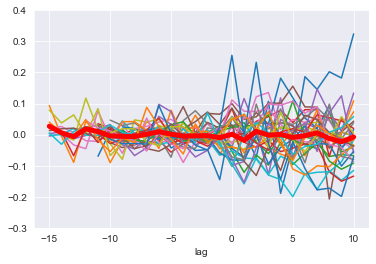

In [38]:
lagged_df[(lagged_df.index>=-15)&(lagged_df.index<=10)].plot(legend=False, ylim=(-.3,.4))
lagged_df[(lagged_df.index>=-15)&(lagged_df.index<=10)].mean(axis=1).plot(linewidth=5, color='red', ylim=(-.3,.4))

<AxesSubplot:xlabel='lag'>

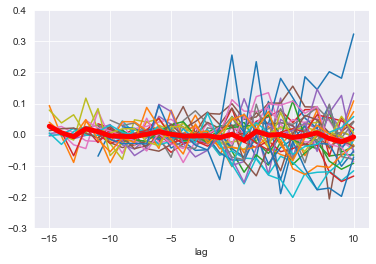

In [39]:
results_df[(results_df.index>=-15)&(results_df.index<=10)].plot(legend=False, ylim=(-.3,.4))
results_df[(results_df.index>=-15)&(results_df.index<=10)].mean(axis=1).plot(linewidth=5, color='red', ylim=(-.3,.4))

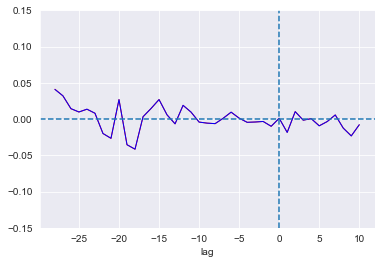

In [40]:
lagged_df[ (lagged_df.index<=10)].mean(axis=1).plot(linewidth=1, color='red', ylim=(-.15,.15))
results_df[ (results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='blue', ylim=(-.15,.15))

plt.axvline(0, linestyle='dashed')
plt.axhline(0, linestyle='dashed')



In [41]:
### Predictions match exactly, so we are good here with one function to fit seperate SCM

# Pooled. One Function

**Pretty sure I'm doing something wrong in this function**

1. What I'm trying to do is take the average pre-treatment across treated units
2. Take average prediction for pre-treatment
3. Only lag 15
4. Square and sum

In [11]:
x

NameError: name 'x' is not defined

In [42]:

def pool_balance_objective(x): 
    x = x.flatten().reshape((17,32))
    
    # pre-treatment treated, average
    t = (test*np.abs(mask-1)).values
    t[t==0]=np.nan
    t = np.nanmean(t, axis=0)
    
    # pre-treatment average-predictions
    c = (np.dot(control,x).T) 
    c = c*np.abs(mask-1)
    c[c==0]=np.nan
    c = np.nanmean(c, axis=0)

    # only fit on lag 15
    imbalance = np.nansum((t-c)[:15]**2)

    
    if penalty == "entropy":
        imbalance += penalty_strength * -np.sum(x * np.log(x))
    elif penalty == "l1":
        imbalance += penalty_strength * np.sum(np.abs(x))
    elif penalty == "l2":
        imbalance += penalty_strength * np.sum(np.square(x))
    else:
        raise NotImplemented(f"Unknown penalty {penalty}")
    return imbalance

simplex_bounds = [(0, 1) for _ in range(544)]



In [43]:
control = np.array(pand.wide_data.loc[[unit for unit in pand.units if unit not in pand.treated_units]]).T 
test = pand.wide_data.loc[pand.treated_units] # * np.abs(mask-1))
x0 = (np.ones((control.shape[1], test.shape[0])) /  control.shape[1] ) #.flatten()

 

In [44]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    res = minimize(
        pool_balance_objective,
        x0.flatten(),
        method="SLSQP",
        bounds=simplex_bounds,
        constraints={'type':'eq', 'fun': lambda x: np.sum(x.reshape(17,32), axis=0) - 1},
    )
        

In [45]:
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0227875980310148
       x: [ 5.243e-02  5.038e-02 ...  7.670e-02  6.914e-02]
     nit: 12
     jac: [ 2.882e-03  3.202e-03 ...  2.888e-03  3.195e-03]
    nfev: 6540
    njev: 12

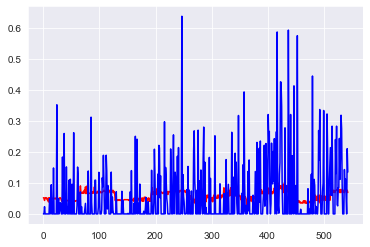

In [46]:
plt.plot(res.x, color='red')
plt.plot(np.array(weights_sep).T.flatten(), color='blue')

In [47]:
pooled_results = {}
y_hat_pooled = control @ res.x.reshape(17,32)

for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values#[-15:]
    x_i = X.T.iloc[t_i==0]#[-15:]
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    pooled_results[t_unit[1]]={}
    pooled_results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    pooled_results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    pooled_results[t_unit[1]]['lagged_outcomes_te'] = pooled_results[t_unit[1]]['lagged_outcomes_act'] - pooled_results[t_unit[1]]['lagged_outcomes_est']
    pooled_results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
        
    
    
    

In [48]:
pooled_results_df = np.empty((0,5))

for k in pooled_results:
    pooled_results_df = np.concatenate([pooled_results_df
                             , np.vstack([np.array(list([k]) * len(pooled_results[k]['lagged_time_units'])) 
                             , np.array(pooled_results[k]['lagged_time_units'])
                             , np.array(pooled_results[k]['lagged_outcomes_te'])
                             , np.array(pooled_results[k]['lagged_outcomes_act'])
                             , np.array(pooled_results[k]['lagged_outcomes_est'])]).T])


In [49]:
pooled_results_df = pd.DataFrame(pooled_results_df)
pooled_results_df.columns =['state','lag', 'pte', 'act', 'est']

In [50]:
pooled_results_df['pte'] = pooled_results_df['pte'].astype(float)

In [51]:
pooled_results_df = pd.pivot_table(pooled_results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
pooled_results_df.index = pooled_results_df.index.astype(int)
pooled_results_df = pooled_results_df.sort_index()


In [52]:

pooled_results_df[pooled_results_df == 0] = np.nan 

Text(0.5, 1.0, 'Pooled')

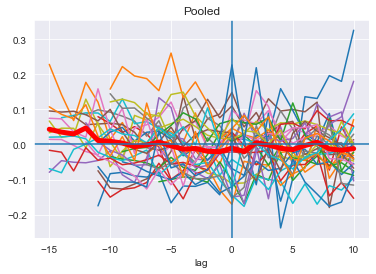

In [53]:
pooled_results_df[(pooled_results_df.index>=-15)&(pooled_results_df.index<=10)].plot(legend=False )
pooled_results_df[(pooled_results_df.index>=-15)&(pooled_results_df.index<=10)].mean(axis=1).plot(linewidth=5, color='red')
plt.axhline(0)
plt.axvline(0)
plt.title("Pooled")


Text(0.5, 1.0, 'Seperate')

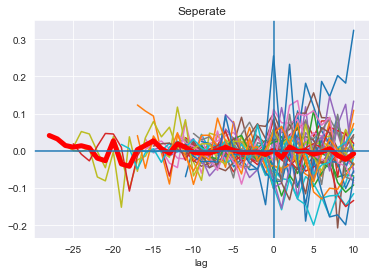

In [54]:
lagged_df[ (lagged_df.index<=10)].plot(legend=False )
lagged_df[(lagged_df.index<=10)].mean(axis=1).plot(linewidth=5, color='red')
plt.axvline(0)
plt.axhline(0)
plt.title("Seperate")


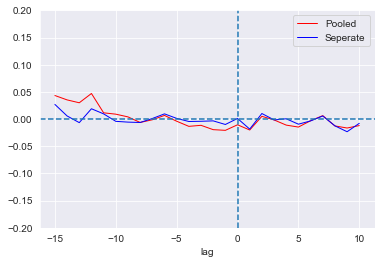

In [55]:
pooled_results_df[(pooled_results_df.index>=-15)&(pooled_results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='red', ylim=(-.3,.4), label='Pooled')
results_df[(results_df.index>=-15)& (results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='blue', ylim=(-.2,.2), label='Seperate')
plt.axvline(0, linestyle='dashed')
plt.axhline(0, linestyle='dashed')
plt.legend()


# Partially Pooled

In [56]:
def part_pool_balance_objective(x): 
    x = x.flatten().reshape((17,32))
     
    state_imbalance = (test.T.values - np.dot(control, x)) * np.abs(mask-1).T
    state_imbalance[state_imbalance == 0] = np.nan 
 
    pooled = np.nansum((state_imbalance[:15:,]))**2
    sep = np.nansum((state_imbalance[:15:,])**2)
    
    imbalance = nu * pooled + (1-nu) * sep

    if penalty == "entropy":
        imbalance += penalty_strength * -np.sum(x * np.log(x))
    elif penalty == "l1":
        imbalance += penalty_strength * np.sum(np.abs(x))
    elif penalty == "l2":
        imbalance += penalty_strength * np.sum(np.square(x))
    else:
        raise NotImplemented(f"Unknown penalty {penalty}")
    return imbalance

simplex_bounds = [(0, 1) for _ in range(544)]

def constraint(x):
    x = x.reshape(17,32)
    return sum(x.sum(axis=0) - np.ones(32))

simplex_constraints = [{"type": "eq", "fun": constraint}]


In [57]:
control = np.array(pand.wide_data.loc[[unit for unit in pand.units if unit not in pand.treated_units]]).T 
test = pand.wide_data.loc[pand.treated_units] # * np.abs(mask-1))
x0 = (np.ones((control.shape[1], test.shape[0])) /  control.shape[1] ) #.flatten()


In [58]:
nu = .5

In [59]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    res = minimize(
        part_pool_balance_objective,
        x0.flatten(),
        method="SLSQP",
        bounds=simplex_bounds,
        constraints=simplex_constraints,
    )

In [60]:
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.24042015674690892
       x: [ 8.608e-18  7.729e-02 ...  2.335e-01  1.426e-01]
     nit: 58
     jac: [ 1.789e-02  8.384e-03 ...  8.256e-03  8.284e-03]
    nfev: 31663
    njev: 58

In [61]:
p_pooled_results = {}

for t_unit in enumerate(y.index):
    # pre-fit 
    t_i = mask[t_unit[0]]
    y_i = y.loc[t_unit[1]].iloc[t_i==0].values[-15:]
    x_i = X.T.iloc[t_i==0][-15:]
    
    pre_treatment_y_hat = x_i @ res.x.reshape(17,32)[:,t_unit[0]]
    post_treatment_y_hat = X.T.iloc[t_i==1] @ res.x.reshape(17,32)[:,t_unit[0]]
    
    pre_y = y_i
    post_y = y.loc[t_unit[1]].iloc[t_i==1].values
    
    p_pooled_results[t_unit[1]]={}
    p_pooled_results[t_unit[1]]['lagged_outcomes_est'] = np.concatenate([pre_treatment_y_hat, post_treatment_y_hat])
    p_pooled_results[t_unit[1]]['lagged_outcomes_act'] = np.concatenate([pre_y, post_y])
    p_pooled_results[t_unit[1]]['lagged_outcomes_te'] = p_pooled_results[t_unit[1]]['lagged_outcomes_act'] - p_pooled_results[t_unit[1]]['lagged_outcomes_est']
    p_pooled_results[t_unit[1]]['lagged_time_units'] = list(range(-len(pre_treatment_y_hat), 0, 1)) + list(range(0, len(post_treatment_y_hat), 1))
        
    

In [62]:
#p_pooled_results

In [63]:
p_pooled_results_df = np.empty((0,5))

for k in p_pooled_results:
    p_pooled_results_df = np.concatenate([p_pooled_results_df
                             , np.vstack([np.array(list([k]) * len(p_pooled_results[k]['lagged_time_units'])) 
                             , np.array(p_pooled_results[k]['lagged_time_units'])
                             , np.array(p_pooled_results[k]['lagged_outcomes_te'])
                             , np.array(p_pooled_results[k]['lagged_outcomes_act'])
                             , np.array(p_pooled_results[k]['lagged_outcomes_est'])]).T])

In [64]:
p_pooled_results_df = pd.DataFrame(p_pooled_results_df)
p_pooled_results_df.columns =['state','lag', 'pte', 'act', 'est']

In [65]:
p_pooled_results_df['pte'] = p_pooled_results_df['pte'].astype(float)

In [66]:
p_pooled_results_df = pd.pivot_table(p_pooled_results_df, index='state', columns='lag', values='pte', aggfunc=np.mean, fill_value=0).T
p_pooled_results_df.index = p_pooled_results_df.index.astype(int)
p_pooled_results_df = p_pooled_results_df.sort_index()
p_pooled_results_df[p_pooled_results_df==0]=np.nan


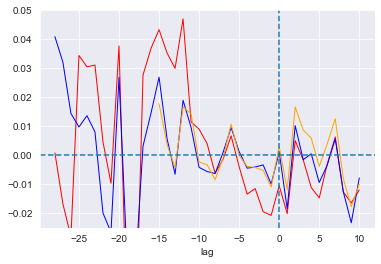

In [67]:
pooled_results_df[(pooled_results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='red', ylim=(-.025,.05))

results_df[ (results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='blue', ylim=(-.025,.05))
p_pooled_results_df[ (p_pooled_results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='orange', ylim=(-.025,.05))
plt.axvline(0,linestyle='dashed')
plt.axhline(0,linestyle='dashed')

(array([5., 2., 4., 5., 4., 0., 2., 1., 0., 1., 3., 0., 0., 0., 1., 2., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.03257282, 0.03700639, 0.04143996, 0.04587352, 0.05030709,
        0.05474066, 0.05917423, 0.06360779, 0.06804136, 0.07247493,
        0.0769085 , 0.08134206, 0.08577563, 0.0902092 , 0.09464277,
        0.09907633, 0.1035099 , 0.10794347, 0.11237704, 0.1168106 ,
        0.12124417, 0.12567774, 0.13011131, 0.13454487, 0.13897844,
        0.14341201, 0.14784558, 0.15227914, 0.15671271, 0.16114628,
        0.16557985]),
 <BarContainer object of 30 artists>)

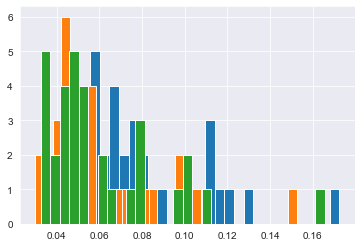

In [68]:
plt.hist(np.sqrt((pooled_results_df**2).mean(axis=0)), bins=30)
plt.hist(np.sqrt((p_pooled_results_df**2).mean(axis=0)), bins=30)
plt.hist(np.sqrt((results_df**2).mean(axis=0)), bins=30)

Text(0.5, 1.0, '')

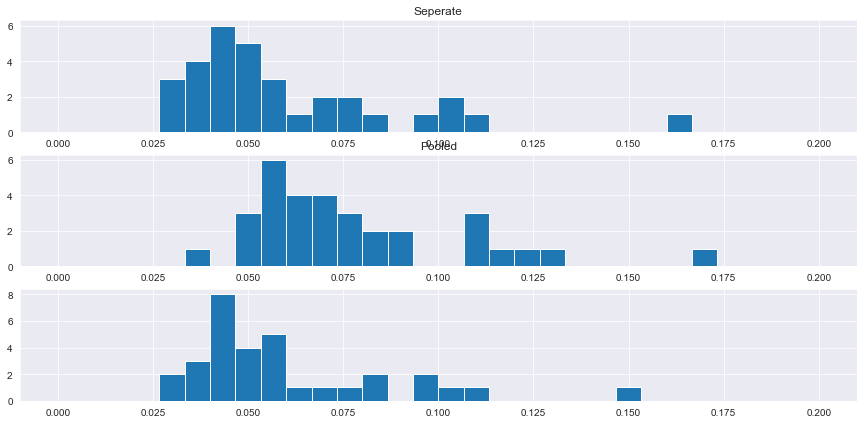

In [69]:
fix, axs = plt.subplots(3,1,figsize=(15,7))

axs[0].hist(np.sqrt((results_df**2).mean(axis=0)), bins=30, range=(0,.2))
axs[0].set_title("Seperate")

axs[1].hist(np.sqrt((pooled_results_df**2).mean(axis=0)), bins=30, range=(0,.2))
axs[1].set_title("Pooled")

axs[2].hist(np.sqrt((p_pooled_results_df**2).mean(axis=0)), bins=30, range=(0,.2))
axs[2].set_title("Partially Pooled")


plt.title("")

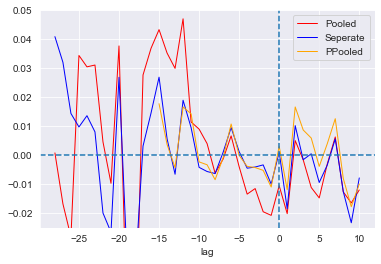

In [70]:
pooled_results_df[(pooled_results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='red', ylim=(-.025,.05), label='Pooled')

results_df[ (results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='blue', ylim=(-.025,.05), label='Seperate')
p_pooled_results_df[ (p_pooled_results_df.index<=10)].mean(axis=1).plot(linewidth=1, color='orange', ylim=(-.025,.05), label='PPooled')
plt.axvline(0,linestyle='dashed')
plt.axhline(0,linestyle='dashed')
plt.legend()

In [71]:
pf = np.sqrt(np.square(pooled_results_df[(pooled_results_df.index<=10)].mean(axis=0)))
sf = np.sqrt(np.square(results_df[(results_df.index<=10)].mean(axis=0)))

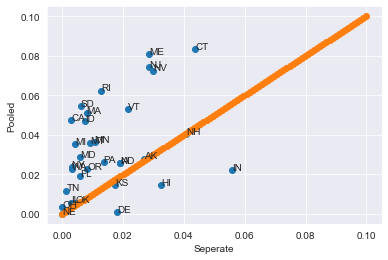

In [72]:
plt.scatter(sf.values, pf.values)
plt.scatter(np.linspace(0, .1, 100), np.linspace(0, .1, 100))
plt.xlabel("Seperate")
plt.ylabel("Pooled")

for i, txt in enumerate(pf.index):
    plt.annotate(txt, (sf.values[i], pf.values[i]))

In [73]:
pf.index

Index(['AK', 'CA', 'CT', 'DE', 'FL', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'MA',
       'MD', 'ME', 'MI', 'MN', 'MT', 'ND', 'NE', 'NH', 'NJ', 'NV', 'NY', 'OH',
       'OK', 'OR', 'PA', 'RI', 'SD', 'TN', 'VT', 'WA'],
      dtype='object', name='state')

In [74]:
sf.index

Index(['AK', 'CA', 'CT', 'DE', 'FL', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'MA',
       'MD', 'ME', 'MI', 'MN', 'MT', 'ND', 'NE', 'NH', 'NJ', 'NV', 'NY', 'OH',
       'OK', 'OR', 'PA', 'RI', 'SD', 'TN', 'VT', 'WA'],
      dtype='object', name='state')